# IMDb Sentiment Analysis

# 05 - So sánh mô hình và thí nghiệm cải tiến

Notebook này tổng hợp kết quả của baseline TF-IDF + Logistic Regression và ba mô hình Transformer gồm DistilBERT, BERT-base và RoBERTa. Mục tiêu là so sánh các mô hình theo hiệu năng trên tập test, AUC, thời gian huấn luyện, kích thước artifact, số tham số và mức độ phù hợp để chọn làm mô hình cuối cùng.

Ngoài phần so sánh chính, notebook cũng kiểm tra khả năng mở rộng thí nghiệm thông qua ablation `MAX_LENGTH`. Qua đó, notebook không chỉ xác định mô hình tốt nhất hiện tại, mà còn chỉ ra những hướng cải thiện hợp lý cho các bước tiếp theo.


## 1. Tổng quan

Mục tiêu của notebook là trả lời ba câu hỏi chính. Thứ nhất, mô hình nào đạt hiệu năng tốt nhất trên tập test độc lập. Thứ hai, các mô hình Transformer cải thiện bao nhiêu so với baseline truyền thống. Thứ ba, mức tăng chi phí về thời gian huấn luyện, kích thước checkpoint và số tham số có hợp lý so với mức cải thiện hiệu năng hay không.

Notebook sẽ đọc lại các metric đã lưu trong `results/metrics/`, training history trong `models/training_logs/`, sau đó xây dựng bảng so sánh tổng hợp, trực quan hóa kết quả, phân tích hiệu quả tài nguyên, kiểm tra thí nghiệm ablation và sao chép checkpoint tốt nhất sang `models/best_model/`.

## 2. Nạp toàn bộ kết quả

Bước đầu tiên trong notebook là đọc lại các file metric JSON của baseline và ba mô hình Transformer, đồng thời nạp training history của DistilBERT, BERT-base và RoBERTa. Các artifact này là nền tảng để xây dựng bảng so sánh tổng hợp ở những bước tiếp theo.

Trong trường hợp checkpoint của một mô hình Transformer đã tồn tại nhưng metric test tương ứng chưa được tạo, notebook có thể tự động đánh giá bổ sung trên test set. Cách thiết kế này giúp quy trình tổng hợp linh hoạt hơn: khi artifact đã đầy đủ, notebook chỉ đọc lại kết quả; khi còn thiếu metric, notebook có thể bổ sung từ checkpoint đã lưu.

In [1]:
from pathlib import Path
import json
import os
import shutil
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from sklearn.metrics import roc_curve
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src import config, dataset as dataset_utils, evaluate, model as model_utils, train as train_utils, visualize
from src.utils import ensure_dirs, get_device, set_seed

set_seed(config.SEED)
ensure_dirs()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_json(path):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return {}
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def normalize_history(data):
    if isinstance(data, dict):
        return data.get("history", [])
    if isinstance(data, list):
        return data
    return []


def has_checkpoint(path):
    path = Path(path)
    return (path / "model.safetensors").exists() or (path / "pytorch_model.bin").exists()

model_order = ["baseline", "distilbert", "bert", "roberta"]
model_metrics = {
    "baseline": load_json(Path(config.METRICS_DIR) / "baseline_results.json"),
    "distilbert": load_json(Path(config.METRICS_DIR) / "distilbert_results.json"),
    "bert": load_json(Path(config.METRICS_DIR) / "bert_results.json"),
    "roberta": load_json(Path(config.METRICS_DIR) / "roberta_results.json"),
}
training_logs = {
    model_key: load_json(Path(config.LOG_DIR) / f"{model_key}_history.json")
    for model_key in ["distilbert", "bert", "roberta"]
}
histories = {model_key: normalize_history(data) for model_key, data in training_logs.items()}

EVALUATE_MISSING_TRANSFORMERS = True
if EVALUATE_MISSING_TRANSFORMERS:
    test_texts, test_labels = dataset_utils.load_data("test")
    for model_key, hf_name in config.TRANSFORMER_MODELS.items():
        if model_metrics.get(model_key):
            continue
        checkpoint_dir = Path(config.MODELS_DIR) / hf_name
        if not has_checkpoint(checkpoint_dir):
            continue
        eval_model, eval_tokenizer = model_utils.load_model_for_inference(str(checkpoint_dir))
        eval_dataset = dataset_utils.IMDbDataset(test_texts, test_labels, eval_tokenizer, max_length=config.MAX_LENGTH)
        eval_loader = DataLoader(eval_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)
        eval_model.to(device)
        model_metrics[model_key] = evaluate.evaluate_model(eval_model, eval_loader, device, model_key)
        del eval_model
        torch.cuda.empty_cache()

loaded_table = pd.DataFrame(
    [
        {
            "model": model_key,
            "has_metrics": bool(model_metrics.get(model_key)),
            "history_rows": len(histories.get(model_key, [])),
        }
        for model_key in model_order
    ]
)
display(loaded_table)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Predicting:   0%|          | 0/310 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicting:   0%|          | 0/310 [00:00<?, ?it/s]

,model,has_metrics,history_rows
0,baseline,True,0
1,distilbert,True,3
2,bert,True,3
3,roberta,True,3


**Nhận xét:**

Bảng trạng thái xác nhận cả bốn mô hình đều đã có metric test để đưa vào so sánh. Baseline không có training history theo epoch, nên `history_rows=0`; trong khi đó, DistilBERT, BERT-base và RoBERTa đều có 3 dòng history, tương ứng với 3 epoch huấn luyện ở notebook 03.

Các log `Loading weights` và `Predicting` cho thấy notebook đã nạp checkpoint và chạy suy diễn bổ sung cho những Transformer chưa có metric test trước đó. Nhờ vậy, các file kết quả trong `results/metrics/` được đồng bộ với checkpoint đã lưu, giúp bảng so sánh phía sau dựa trên cùng một quy trình đánh giá.

## 3. Bảng so sánh toàn diện

Bảng tổng hợp dưới đây kết hợp các thông tin quan trọng của từng mô hình, gồm hiệu năng trên test set, AUC, số tham số, kích thước artifact và thời gian huấn luyện. Việc đặt baseline và các mô hình Transformer trong cùng một bảng giúp đánh giá đồng thời hai khía cạnh: chất lượng dự đoán và chi phí tài nguyên.

Tiêu chí chính để xếp hạng là F1 macro trên tập test, vì chỉ số này đánh giá hai lớp `negative` và `positive` với trọng số ngang nhau. Các tiêu chí phụ như accuracy, AUC, thời gian huấn luyện và kích thước mô hình được dùng để phân tích mức đánh đổi giữa hiệu năng và chi phí.

In [2]:
parameter_priors = {
    "baseline": 50000,
    "distilbert": 66955010,
    "bert": 109483778,
    "roberta": 124647170,
}
size_priors_mb = {
    "baseline": 1.0,
    "distilbert": 255.0,
    "bert": 418.0,
    "roberta": 475.0,
}

def best_history_value(model_key, field):
    history = histories.get(model_key, [])
    if not history:
        return None
    best_row = max(history, key=lambda row: row.get("val_f1", -1.0))
    return best_row.get(field)

comparison_rows = []
for model_key in model_order:
    metrics = model_metrics.get(model_key, {}) or {}
    train_time = None
    if model_key == "baseline":
        baseline_log = load_json(Path(config.LOG_DIR) / "baseline_results.json")
        train_time = baseline_log.get("training_time_seconds")
    else:
        log_data = training_logs.get(model_key, {})
        train_time = log_data.get("total_train_time_seconds") if isinstance(log_data, dict) else None
    comparison_rows.append(
        {
            "model": model_key,
            "params": parameter_priors.get(model_key),
            "size_mb": size_priors_mb.get(model_key),
            "train_time_seconds": train_time,
            "accuracy": metrics.get("accuracy"),
            "f1_macro": metrics.get("f1_macro", metrics.get("f1")),
            "precision_macro": metrics.get("precision_macro", metrics.get("precision")),
            "recall_macro": metrics.get("recall_macro", metrics.get("recall")),
            "roc_auc": metrics.get("roc_auc", metrics.get("auc")),
            "best_val_f1": best_history_value(model_key, "val_f1"),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
ranked_df = comparison_df.sort_values("f1_macro", ascending=False, na_position="last").reset_index(drop=True)
if not ranked_df.empty and pd.notna(ranked_df.loc[0, "f1_macro"]):
    ranked_df.loc[0, "model"] = ranked_df.loc[0, "model"] + " *"
display(ranked_df)

summary_path = Path(config.METRICS_DIR) / "comparison_summary.json"
summary_payload = comparison_df.replace({np.nan: None}).set_index("model").to_dict(orient="index")
with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(summary_payload, file, indent=2)
print(f"Saved comparison summary: {summary_path}")


,model,params,size_mb,train_time_seconds,accuracy,f1_macro,precision_macro,recall_macro,roc_auc,best_val_f1
0,roberta *,124647170,475.0,3204.742985,0.941319,0.941318,0.941317,0.941323,0.985300,0.945135
1,bert,109483778,418.0,3196.381603,0.917927,0.917835,0.919477,0.917812,0.975922,0.927782
2,baseline,50000,1.0,26.449648,0.908651,0.908618,0.909061,0.908592,0.968102,NaN
3,distilbert,66955010,255.0,1746.005927,0.908248,0.908118,0.910190,0.908117,0.971149,0.921940


Saved comparison summary: /kaggle/working/imdb_sentiment_analysis/results/metrics/comparison_summary.json


**Nhận xét:**

Bảng so sánh cho thấy `RoBERTa` là mô hình dẫn đầu theo F1 macro trên tập test, đạt 94.13% accuracy, 94.13% F1 macro và AUC 0.9853. So với `BERT-base`, `RoBERTa` cao hơn 2.34 điểm phần trăm accuracy và 2.35 điểm phần trăm F1 macro. So với baseline TF-IDF + Logistic Regression, `RoBERTa` cao hơn 3.27 điểm phần trăm accuracy, 3.27 điểm phần trăm F1 macro và 0.0172 AUC.

`BERT-base` đứng thứ hai với 91.79% accuracy và 91.78% F1 macro. Tuy nhiên, thời gian huấn luyện của `BERT-base` gần tương đương `RoBERTa`, trong khi F1 macro thấp hơn đáng kể. Điều này cho thấy `BERT-base` không phải lựa chọn tối ưu trong nhóm Transformer nếu xét đồng thời hiệu năng và chi phí huấn luyện.

Một kết quả đáng chú ý là `DistilBERT` thấp hơn baseline 0.04 điểm phần trăm accuracy và 0.05 điểm phần trăm F1 macro trong cấu hình hiện tại, dù AUC cao hơn baseline 0.0030. Vì vậy, `DistilBERT` không phải lựa chọn tốt nhất nếu mục tiêu chính là accuracy hoặc F1 macro, nhưng vẫn cho thấy khả năng xếp hạng xác suất nhỉnh hơn baseline.

## 4. Bộ trực quan hóa so sánh

Phần này trực quan hóa kết quả so sánh mô hình bằng các biểu đồ tổng hợp. Bar chart giúp đối chiếu trực tiếp các metric chính giữa các mô hình, còn radar chart cho phép quan sát nhanh hình dạng hiệu năng tổng thể trên nhiều tiêu chí cùng lúc.

Các hình được lưu tại `results/figures/model_comparison_bar.png` và `results/figures/model_comparison_radar.png`. Những biểu đồ này đóng vai trò bổ sung cho bảng metric ở phần trước, giúp việc so sánh giữa baseline và các mô hình Transformer trở nên trực quan hơn.

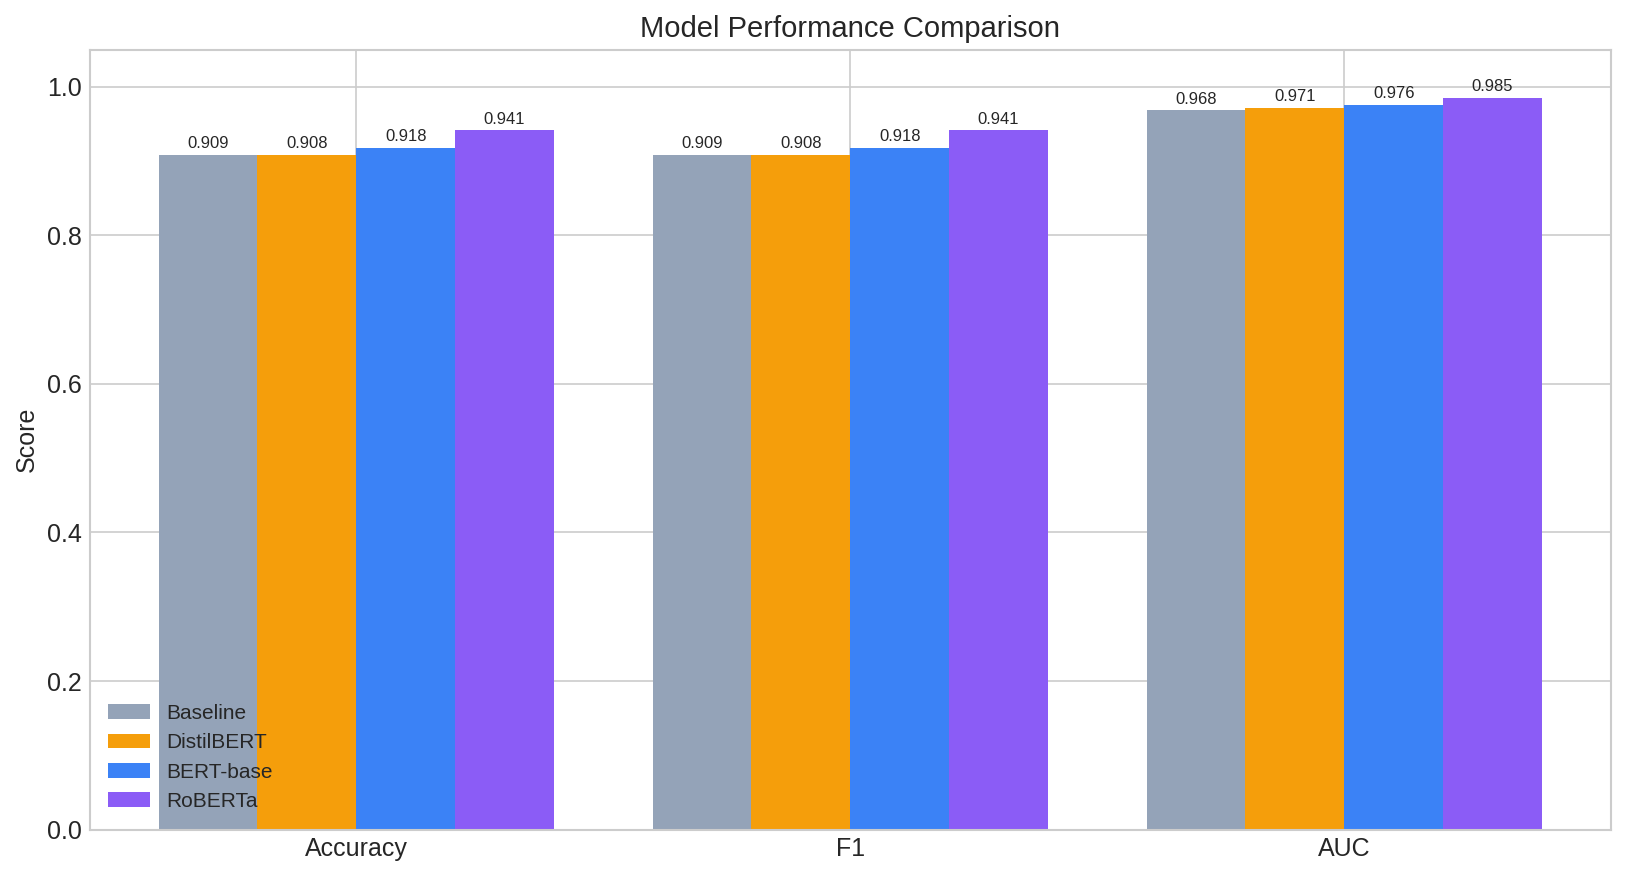

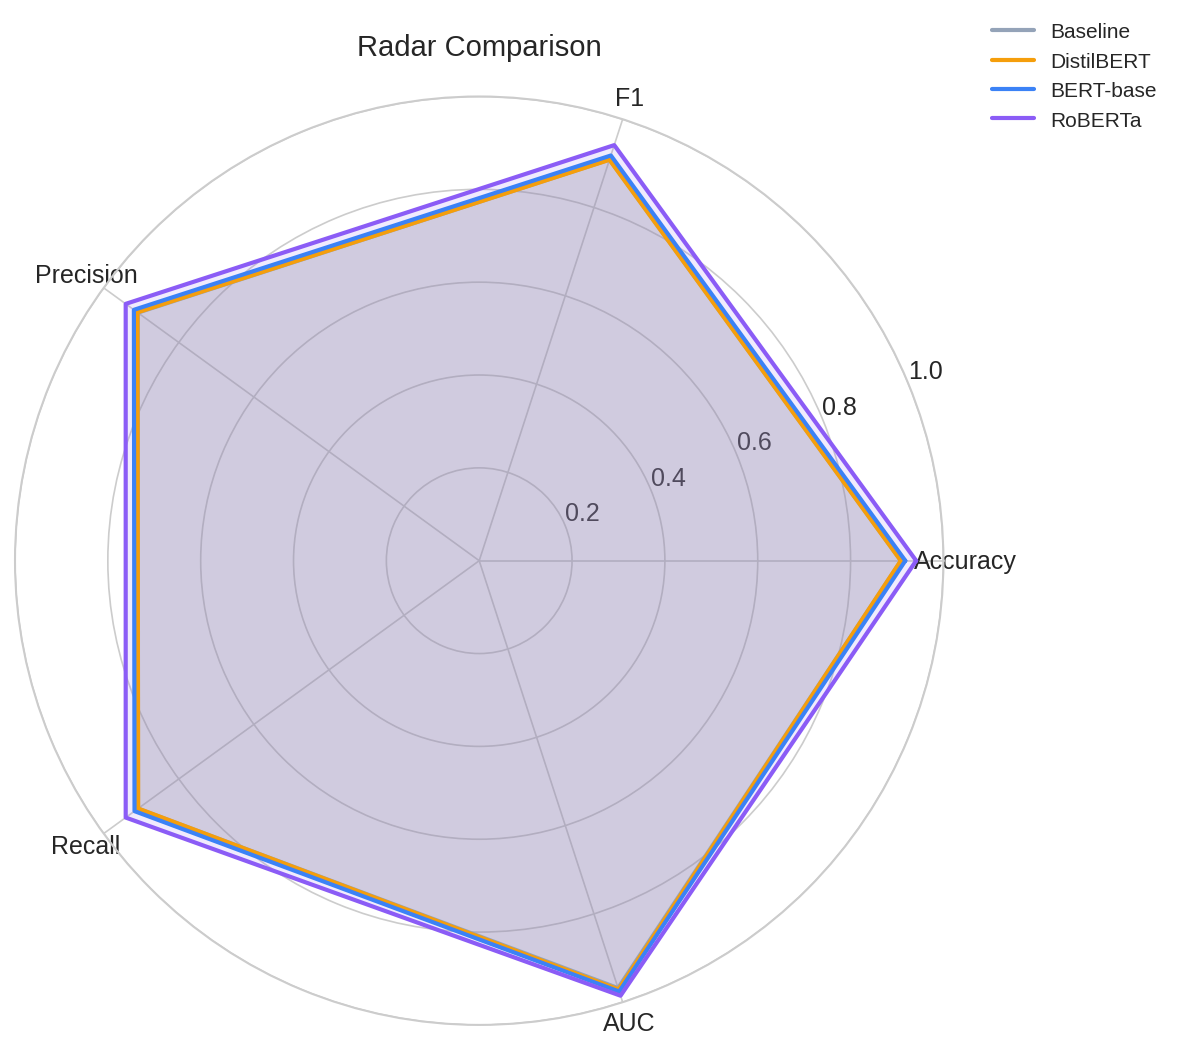

In [3]:
valid_metrics = {key: value for key, value in model_metrics.items() if value}
if valid_metrics:
    bar_path = str(Path(config.FIGURES_DIR) / "model_comparison_bar.png")
    radar_path = str(Path(config.FIGURES_DIR) / "model_comparison_radar.png")
    visualize.plot_model_comparison_bar(valid_metrics, bar_path)
    visualize.plot_model_comparison_radar(valid_metrics, radar_path)
    display(Image(filename=bar_path))
    display(Image(filename=radar_path))
else:
    print("No metrics available for comparison plots.")


**Nhận xét:**

Bar chart và radar chart trực quan hóa lại xu hướng đã thấy trong bảng so sánh: `RoBERTa` bao phủ vùng lớn nhất trên radar chart và có cột cao nhất ở cả accuracy, F1 macro và AUC. Điều này xác nhận rằng lợi thế của `RoBERTa` là nhất quán trên nhiều tiêu chí, không chỉ xuất hiện ở một metric đơn lẻ.

`BERT-base` là mô hình đứng sau `RoBERTa`, trong khi baseline và `DistilBERT` nằm rất gần nhau trên accuracy và F1 macro. Điểm khác biệt đáng chú ý là `DistilBERT` nhỉnh hơn baseline về AUC, nhưng không chuyển hóa lợi thế này thành accuracy hoặc F1 cao hơn tại threshold mặc định.

Như vậy, các biểu đồ này đóng vai trò kiểm chứng trực quan cho bảng metric: `RoBERTa` là lựa chọn mạnh nhất về hiệu năng tổng thể, còn baseline vẫn là mốc truyền thống rất cạnh tranh so với `DistilBERT` trong cấu hình hiện tại.

### 4.1. ROC overlay

Biểu đồ ROC overlay chồng các đường ROC của baseline và ba mô hình Transformer trên cùng một hệ trục để so sánh khả năng phân tách hai lớp trên nhiều ngưỡng quyết định khác nhau. Khác với accuracy hoặc F1 macro, vốn phụ thuộc vào một threshold cụ thể, ROC curve cho phép đánh giá chất lượng xếp hạng xác suất của mô hình trên toàn bộ dải ngưỡng.

Dữ liệu để vẽ ROC được lấy từ xác suất dự đoán đã lưu trong các file metric JSON. Biểu đồ kết quả được lưu tại `results/figures/roc_curves_comparison.png`.

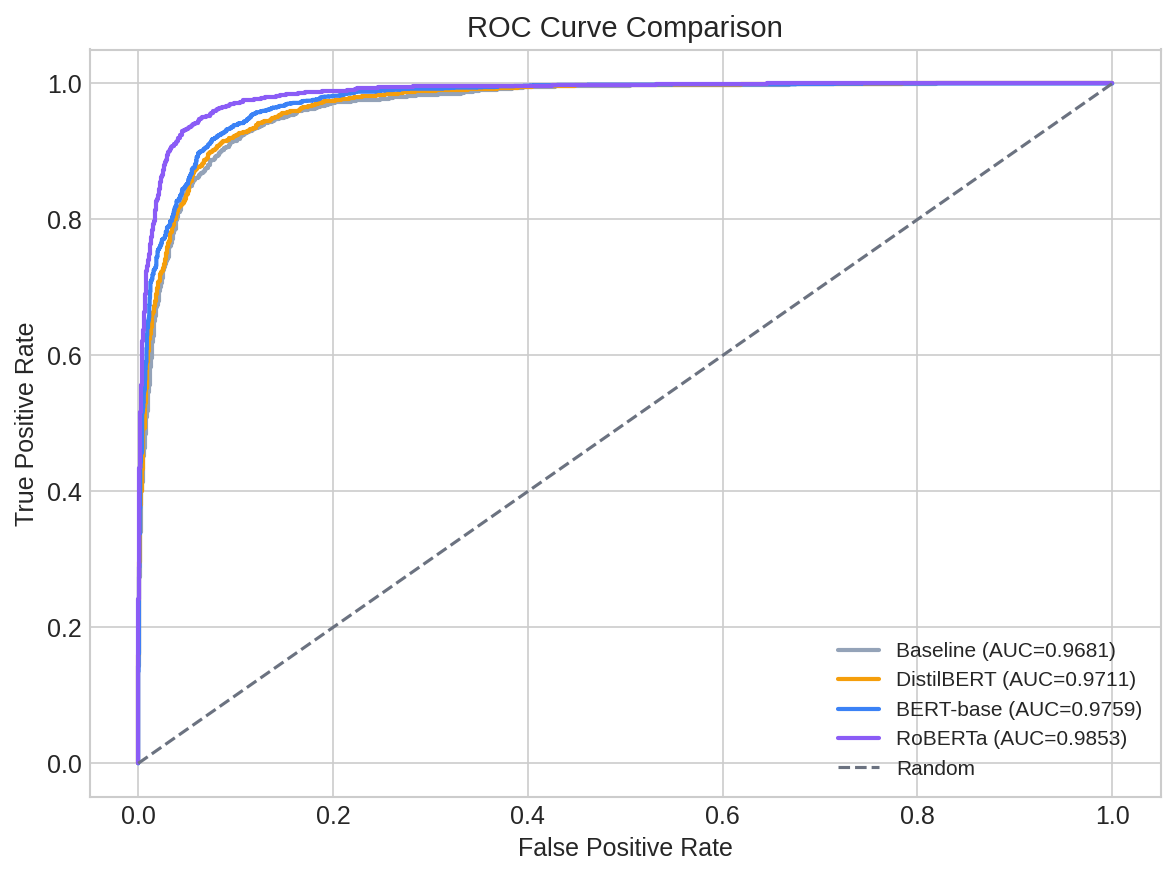

In [4]:
roc_data = {}
test_labels_for_roc = None
if (Path(config.DATA_DIR) / "test.csv").exists():
    test_labels_for_roc = pd.read_csv(Path(config.DATA_DIR) / "test.csv")["label_id"].astype(int).to_numpy()

for model_key, metrics in valid_metrics.items():
    probabilities = metrics.get("probabilities")
    true_labels = metrics.get("true_labels", test_labels_for_roc.tolist() if test_labels_for_roc is not None else None)
    if probabilities is None or true_labels is None:
        continue
    probabilities_array = np.asarray(probabilities)
    true_array = np.asarray(true_labels)
    fpr, tpr, _ = roc_curve(true_array, probabilities_array[:, config.LABEL2ID["positive"]])
    roc_data[model_key] = {"fpr": fpr, "tpr": tpr, "auc": metrics.get("roc_auc", metrics.get("auc"))}

if roc_data:
    roc_overlay_path = str(Path(config.FIGURES_DIR) / "roc_curves_comparison.png")
    visualize.plot_roc_curves_comparison(roc_data, roc_overlay_path)
    display(Image(filename=roc_overlay_path))
else:
    print("No probability data available for ROC overlay.")


**Nhận xét:**

ROC overlay cho thấy cả bốn mô hình đều nằm khá xa đường chéo ngẫu nhiên, xác nhận rằng tất cả đều có khả năng phân tách hai lớp tốt hơn đáng kể so với dự đoán ngẫu nhiên. Tuy nhiên, mức độ tách lớp giữa các mô hình vẫn có khác biệt rõ ràng.

`RoBERTa` đạt AUC cao nhất là 0.9853, tiếp theo là `BERT-base` với 0.9759, `DistilBERT` với 0.9711 và baseline với 0.9681. So với `BERT-base`, `RoBERTa` cao hơn 0.0094 AUC; so với `DistilBERT`, cao hơn 0.0142; và so với baseline, cao hơn 0.0172.

Về mặt trực quan, đường ROC của `RoBERTa` cũng nằm phía trên các mô hình còn lại trên phần lớn miền giá trị của False Positive Rate, đặc biệt ở vùng FPR thấp. Điều này cho thấy `RoBERTa` duy trì True Positive Rate cao hơn khi vẫn kiểm soát tốt False Positive Rate, tức là mô hình có chất lượng xếp hạng xác suất tốt nhất trong số các mô hình được so sánh.

Kết quả này củng cố nhận định từ bảng metric trước đó: lợi thế của `RoBERTa` không chỉ xuất hiện ở accuracy hay F1 macro tại threshold mặc định, mà còn thể hiện ở khả năng phân tách hai lớp một cách ổn định trên nhiều ngưỡng quyết định khác nhau.

### 4.2. So sánh đường cong huấn luyện

Đường cong huấn luyện được so sánh cho ba mô hình Transformer dựa trên validation loss, validation accuracy và validation F1 qua từng epoch. Baseline TF-IDF + Logistic Regression không được đưa vào biểu đồ này vì không có quá trình fine-tuning theo epoch giống các mô hình Transformer.

Nhóm biểu đồ này giúp đánh giá tốc độ cải thiện trên validation set, mức độ ổn định qua từng epoch và dấu hiệu overfitting của mỗi kiến trúc.


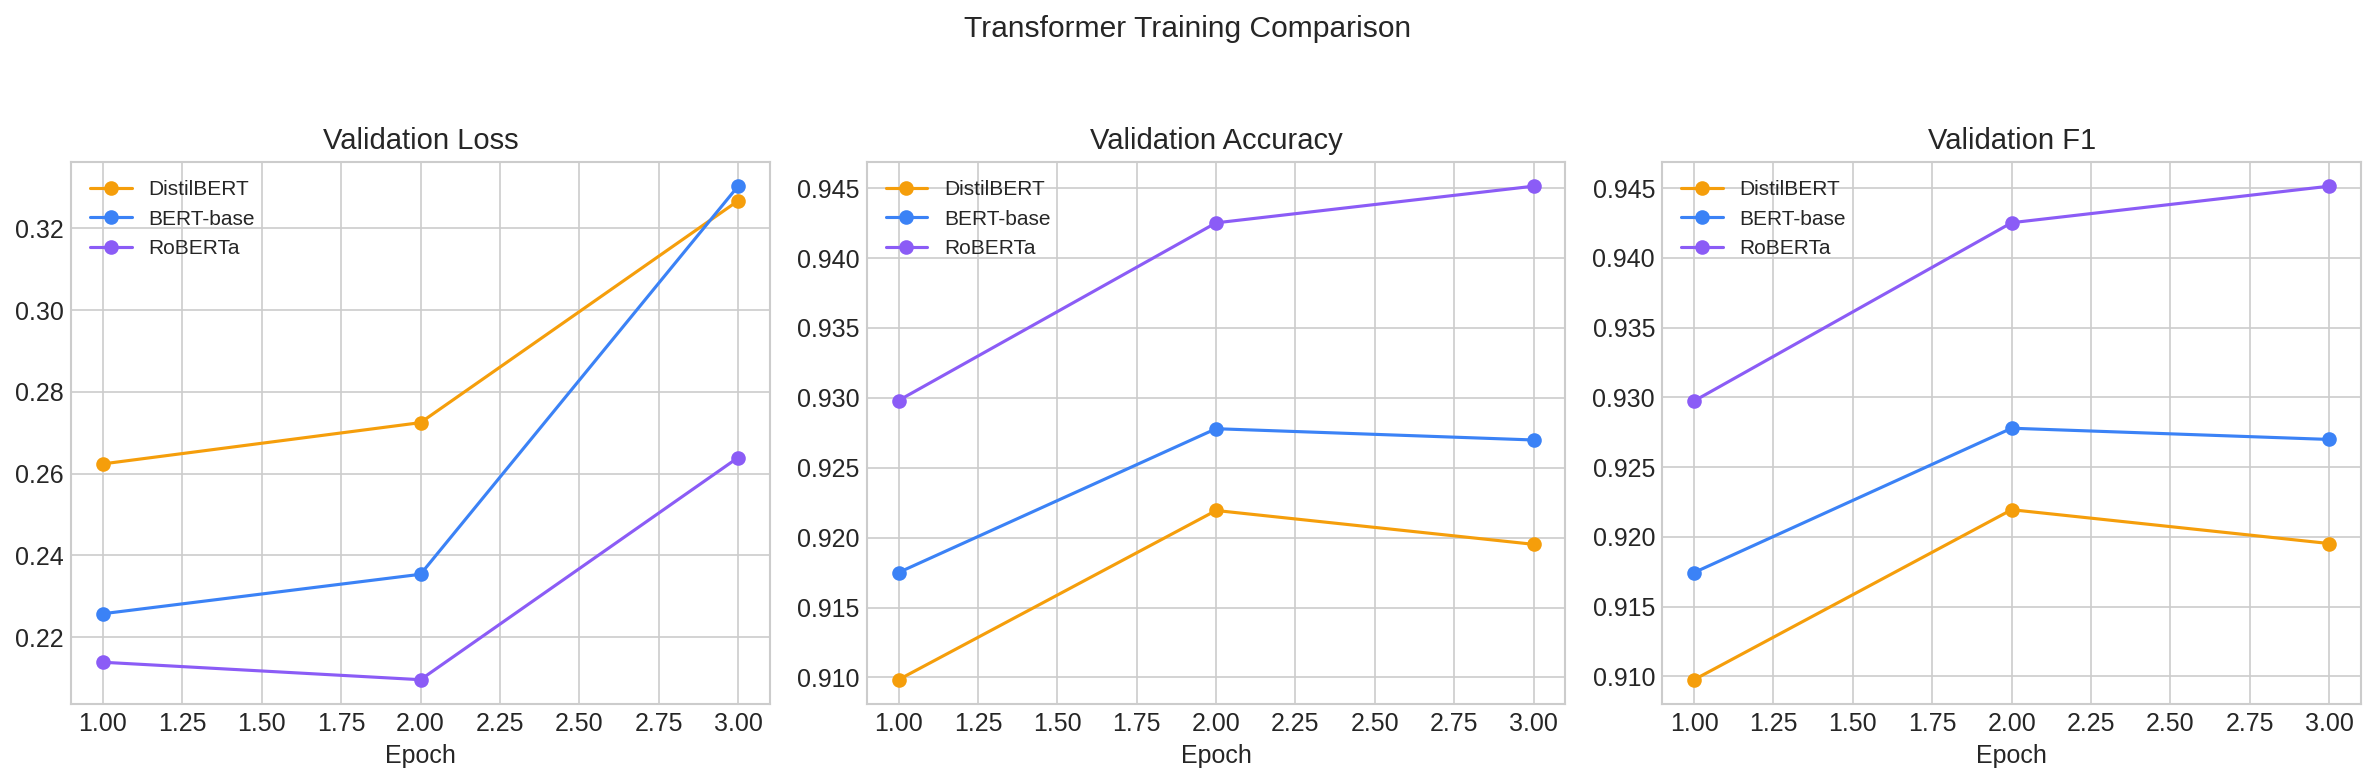

In [5]:
non_empty_histories = {key: value for key, value in histories.items() if value}
if non_empty_histories:
    training_comparison_path = str(Path(config.FIGURES_DIR) / "training_curves_comparison.png")
    visualize.plot_training_curves_comparison(non_empty_histories, training_comparison_path)
    display(Image(filename=training_comparison_path))
else:
    print("No Transformer histories available.")


**Nhận xét:**

Biểu đồ cho thấy `RoBERTa` đạt validation accuracy và validation F1 cao nhất trong cả ba epoch. Validation F1 của mô hình tiếp tục tăng đến epoch 3 và đạt khoảng 94.51%. Ngược lại, `BERT-base` và `DistilBERT` đều đạt F1 tốt nhất ở epoch 2 rồi giảm nhẹ ở epoch 3, cho thấy hiệu năng validation bắt đầu chững lại sau epoch thứ hai.

Về validation loss, `RoBERTa` đạt mức thấp nhất ở epoch 2 rồi tăng ở epoch 3. Điều này cho thấy mô hình vẫn cải thiện theo F1, nhưng đã bắt đầu xuất hiện dấu hiệu overfitting nhẹ ở cuối quá trình fine-tuning. `DistilBERT` và `BERT-base` có validation loss tăng rõ hơn qua các epoch sau, nên hai mô hình này có xu hướng overfit sớm hơn.

Nhìn chung, đường cong huấn luyện củng cố kết luận rằng `RoBERTa` là mô hình Transformer ổn định và hiệu quả nhất trong cấu hình thí nghiệm hiện tại: đạt F1 cao nhất, duy trì hiệu năng validation tốt hơn qua các epoch và chỉ bắt đầu bộc lộ overfitting ở giai đoạn cuối.

## 5. Phân tích hiệu quả tài nguyên

Hiệu năng cao hơn thường đi kèm chi phí lớn hơn về số tham số, thời gian huấn luyện và kích thước checkpoint. Vì vậy, bên cạnh accuracy và F1 macro, cần đánh giá mức cải thiện của từng mô hình trong tương quan với độ phức tạp tài nguyên.

Bước phân tích này so sánh accuracy với số tham số của từng mô hình, đồng thời tính mức tăng accuracy so với baseline trên mỗi triệu tham số. Cách nhìn này giúp xác định mô hình nào mang lại cải thiện đáng kể, và mô hình nào có chi phí tăng nhưng lợi ích thực nghiệm chưa tương xứng.

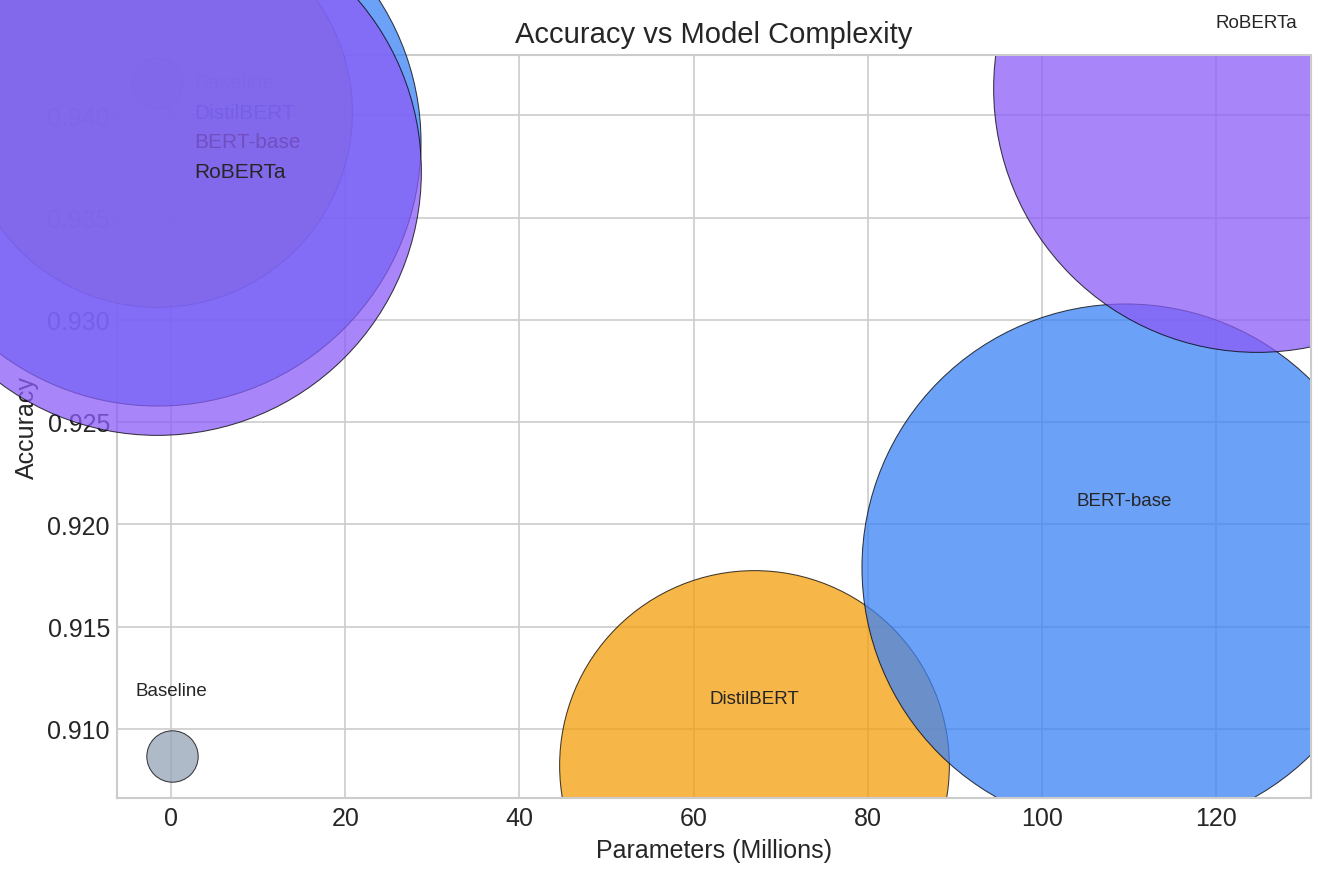

,model,accuracy_gain,params_millions,gain_per_million_params
2,roberta,0.032668,124.647170,0.000262
1,bert,0.009276,109.483778,0.000085
0,distilbert,-0.000403,66.955010,-0.000006


In [6]:
efficiency_stats = {}
for _, row in comparison_df.iterrows():
    if pd.isna(row["accuracy"]):
        continue
    efficiency_stats[row["model"]] = {
        "params_millions": row["params"] / 1_000_000,
        "accuracy": row["accuracy"],
        "train_time_seconds": row["train_time_seconds"] or 0.0,
    }

if efficiency_stats:
    efficiency_path = str(Path(config.FIGURES_DIR) / "efficiency_comparison.png")
    visualize.plot_efficiency_comparison(efficiency_stats, efficiency_path)
    display(Image(filename=efficiency_path))
else:
    print("No efficiency data available.")

baseline_accuracy = comparison_df.loc[comparison_df["model"] == "baseline", "accuracy"].dropna()
if not baseline_accuracy.empty:
    base_acc = baseline_accuracy.iloc[0]
    gain_rows = []
    for _, row in comparison_df.iterrows():
        if row["model"] == "baseline" or pd.isna(row["accuracy"]):
            continue
        gain_rows.append(
            {
                "model": row["model"],
                "accuracy_gain": row["accuracy"] - base_acc,
                "params_millions": row["params"] / 1_000_000,
                "gain_per_million_params": (row["accuracy"] - base_acc) / (row["params"] / 1_000_000),
            }
        )
    display(pd.DataFrame(gain_rows).sort_values("gain_per_million_params", ascending=False))


**Nhận xét:**

Biểu đồ accuracy theo số tham số cho thấy sự đánh đổi rõ ràng giữa hiệu năng và độ phức tạp mô hình. Baseline có số tham số và kích thước artifact rất nhỏ, thời gian huấn luyện chỉ 26.45 giây, nhưng vẫn đạt 90.87% accuracy. Ngược lại, `RoBERTa` có 124.65 triệu tham số, thời gian huấn luyện 3,204.74 giây và đạt accuracy cao nhất 94.13%.

Theo bảng gain-per-parameter, `RoBERTa` tăng 3.27 điểm phần trăm accuracy so với baseline, tương đương khoảng 0.0262 điểm phần trăm trên mỗi triệu tham số. `BERT-base` tăng 0.93 điểm phần trăm, tương đương khoảng 0.0085 điểm phần trăm trên mỗi triệu tham số. Trong khi đó, `DistilBERT` thấp hơn baseline 0.04 điểm phần trăm accuracy trong cấu hình hiện tại, nên không tạo ra lợi ích accuracy dù có AUC cao hơn.

Từ góc nhìn tài nguyên, baseline vẫn là lựa chọn nhỏ nhất, nhanh nhất và có hiệu quả chi phí rất cao. `RoBERTa` là lựa chọn phù hợp nếu ưu tiên chất lượng dự đoán tuyệt đối. `BERT-base` kém hấp dẫn hơn trong thí nghiệm này vì thời gian huấn luyện gần tương đương `RoBERTa`, nhưng F1 macro thấp hơn 2.35 điểm phần trăm. `DistilBERT` có lợi thế về tốc độ so với hai Transformer lớn hơn, nhưng chưa vượt được baseline về accuracy và F1 macro.

## 6. Thí nghiệm ablation cho `MAX_LENGTH`

Sau các phân tích về truncation và độ dài review, `MAX_LENGTH` là một biến thí nghiệm đáng kiểm tra thêm. Về mặt giả thuyết, tăng `MAX_LENGTH` có thể giúp mô hình quan sát được nhiều nội dung hơn trong các review dài, đặc biệt là những trường hợp kết luận sentiment hoặc tín hiệu đảo chiều xuất hiện ở cuối văn bản.

Khối lệnh dưới đây được thiết kế để chạy ablation với các giá trị `MAX_LENGTH` khác nhau, chẳng hạn `128` và `512`. Nếu thí nghiệm được bật, notebook sẽ fine-tune lại mô hình tốt nhất với từng cấu hình độ dài, đánh giá trên test set và lưu kết quả vào `results/metrics/max_length_ablation_results.json`.

Vì đây là thí nghiệm tốn tài nguyên hơn các bước tổng hợp thông thường, biến `RUN_MAX_LENGTH_ABLATION` được dùng để kiểm soát việc có chạy ablation hay không.

In [7]:
RUN_MAX_LENGTH_ABLATION = False
ABLATION_LENGTHS = [128, 512]
ablation_path = Path(config.METRICS_DIR) / "max_length_ablation_results.json"

if RUN_MAX_LENGTH_ABLATION:
    best_available = comparison_df.dropna(subset=["f1_macro"]).sort_values("f1_macro", ascending=False).iloc[0]["model"].replace(" *", "")
    if best_available == "baseline":
        raise ValueError("MAX_LENGTH ablation requires a Transformer model.")
    hf_name = config.TRANSFORMER_MODELS[best_available]
    ablation_results = []
    for max_length in ABLATION_LENGTHS:
        tokenizer = model_utils.load_tokenizer(hf_name)
        model = model_utils.load_model_for_training(hf_name)
        train_loader, val_loader, test_loader = dataset_utils.create_dataloaders(
            tokenizer,
            max_length=max_length,
            batch_size=config.BATCH_SIZE,
            num_workers=0,
        )
        train_result = train_utils.train_model(
            f"{best_available}_maxlen_{max_length}",
            model,
            tokenizer,
            train_loader,
            val_loader,
            device,
        )
        test_metrics = evaluate.evaluate_model(model, test_loader, device, f"{best_available}_maxlen_{max_length}")
        ablation_results.append(
            {
                "max_length": max_length,
                "test_accuracy": test_metrics["accuracy"],
                "test_f1": test_metrics["f1_macro"],
                "train_time_seconds": train_result["total_train_time_seconds"],
            }
        )
        del model
        torch.cuda.empty_cache()
    with open(ablation_path, "w", encoding="utf-8") as file:
        json.dump(ablation_results, file, indent=2)
else:
    print("Set RUN_MAX_LENGTH_ABLATION=True to run this experiment.")

ablation_results = load_json(ablation_path)
if ablation_results:
    display(pd.DataFrame(ablation_results))
else:
    display(pd.DataFrame(columns=["max_length", "coverage", "test_accuracy", "test_f1", "train_time_seconds", "memory"]))


Set RUN_MAX_LENGTH_ABLATION=True to run this experiment.


,max_length,coverage,test_accuracy,test_f1,train_time_seconds,memory


**Nhận xét:**

Trong lần chạy hiện tại, `RUN_MAX_LENGTH_ABLATION=False`, nên thí nghiệm ablation với `MAX_LENGTH=128` và `MAX_LENGTH=512` chưa được thực thi. Artifact `results/metrics/max_length_ablation_results.json` cũng chưa tồn tại, vì vậy chưa có kết quả định lượng để so sánh trực tiếp các cấu hình độ dài đầu vào.

Tuy chưa có kết quả ablation, các phân tích ở notebook 04 cho thấy độ dài đầu vào là một yếu tố đáng chú ý. Nhóm review không bị truncation đạt 95.40% accuracy, trong khi nhóm bị truncation đạt 92.15%, thấp hơn 3.25 điểm phần trăm. Khoảng cách này cho thấy việc cắt chuỗi có thể làm mất thông tin sentiment quan trọng trong các review dài.

Do đó, `MAX_LENGTH=512` được xem là một hướng thí nghiệm tiếp theo có cơ sở thực nghiệm. Tuy nhiên, ảnh hưởng thật sự của cấu hình này đến accuracy, F1 và chi phí huấn luyện chỉ có thể được kết luận sau khi chạy ablation đầy đủ.

## 7. Chọn mô hình tốt nhất và sao chép checkpoint

Sau khi đã tổng hợp hiệu năng và chi phí của toàn bộ mô hình, bước này chọn mô hình cuối cùng dựa trên `f1_macro` trên tập test. `F1 macro` được dùng làm tiêu chí chính vì chỉ số này đánh giá hai lớp `negative` và `positive` với trọng số ngang nhau.

Các chỉ số như accuracy và AUC, cùng với thời gian huấn luyện và kích thước mô hình, được dùng để diễn giải thêm mức đánh đổi giữa hiệu năng và chi phí. Nếu mô hình được chọn là một Transformer, checkpoint tương ứng sẽ được sao chép vào `models/best_model/` để các bước suy diễn hoặc app demo có thể nạp mô hình từ một đường dẫn thống nhất.

In [8]:
ranked_models = comparison_df.dropna(subset=["f1_macro"]).sort_values("f1_macro", ascending=False)
if ranked_models.empty:
    raise ValueError("No evaluated model is available for selection.")

best_key = ranked_models.iloc[0]["model"]
best_f1 = ranked_models.iloc[0]["f1_macro"]
best_accuracy = ranked_models.iloc[0]["accuracy"]
print(f"Selected model: {best_key} (accuracy={best_accuracy:.4f}, f1_macro={best_f1:.4f})")

if best_key != "baseline":
    source_dir = Path(config.MODELS_DIR) / config.TRANSFORMER_MODELS[best_key]
    if has_checkpoint(source_dir):
        destination = Path(config.BEST_MODEL_DIR)
        if destination.exists():
            shutil.rmtree(destination)
        shutil.copytree(source_dir, destination)
        print(f"Copied checkpoint to {destination}")
    else:
        print(f"Checkpoint not found for {best_key}: {source_dir}")
else:
    print("Baseline selected; no Transformer checkpoint was copied.")


Selected model: roberta (accuracy=0.9413, f1_macro=0.9413)
Copied checkpoint to /kaggle/working/imdb_sentiment_analysis/models/best_model


**Nhận xét:**

Kết quả lựa chọn cho thấy `RoBERTa` là mô hình tốt nhất theo `f1_macro` trên tập test, với accuracy 94.13% và F1 macro 94.13%. Kết quả này nhất quán với các phân tích trước đó, trong đó `RoBERTa` cũng đứng đầu về AUC với giá trị 0.9853.

Checkpoint của `RoBERTa` đã được sao chép vào `models/best_model/`. Thư mục này chứa các file cần thiết cho quá trình suy diễn, chẳng hạn `config.json`, `model.safetensors`, `tokenizer.json` và `tokenizer_config.json`.

Việc chuẩn hóa checkpoint cuối cùng vào `models/best_model/` giúp pipeline suy diễn hoặc app demo có thể nạp mô hình từ một đường dẫn thống nhất. Trong cấu trúc dự án hiện tại, `SentimentPredictor` có thể sử dụng thư mục này làm checkpoint mặc định cho mô hình cuối cùng.

### 7.1. Tổng hợp câu hỏi báo cáo

Sau khi chọn mô hình cuối cùng, notebook tổng hợp các câu hỏi quan trọng nhất của thí nghiệm: Transformer cải thiện bao nhiêu so với baseline, loại review nào khó nhất, các kỹ thuật fine-tuning có vai trò gì và hướng cải thiện tiếp theo là gì.

Bảng bên dưới hệ thống hóa lại các kết luận chính từ những phân tích trước đó, giúp chuẩn bị cho phần tổng kết cuối cùng của notebook.

In [9]:
answers = []
baseline_row = comparison_df[comparison_df["model"] == "baseline"]
best_row = ranked_models.iloc[0]
if not baseline_row.empty and pd.notna(baseline_row.iloc[0]["accuracy"]):
    base_row = baseline_row.iloc[0]
    answers.append(
        {
            "question": "Transformer improvement over baseline",
            "answer": f"Best model accuracy is {best_row['accuracy']:.4f} versus baseline {base_row['accuracy']:.4f}; F1 is {best_row['f1_macro']:.4f} versus {base_row['f1_macro']:.4f}.",
        }
    )
answers.extend(
    [
        {
            "question": "Hardest review types",
            "answer": "Sarcasm, negation, mixed sentiment, and long reviews are the hardest cases according to the error analysis.",
        },
        {
            "question": "Fine-tuning tricks",
            "answer": "Warmup, weight decay, and gradient clipping are supported when validation curves remain stable and the train-validation gap is small.",
        },
        {
            "question": "Best gain per complexity",
            "answer": "The comparison table and gain-per-parameter calculation identify the most efficient upgrade from baseline.",
        },
        {
            "question": "Next work with more time",
            "answer": "Run MAX_LENGTH=512 fully, tune learning rates, test cosine scheduling, and try domain-adaptive pretraining on unlabeled movie reviews.",
        },
    ]
)
display(pd.DataFrame(answers))


,question,answer
0,Transformer improvement over baseline,Best model accuracy is 0.9413 versus baseline ...
1,Hardest review types,"Sarcasm, negation, mixed sentiment, and long r..."
2,Fine-tuning tricks,"Warmup, weight decay, and gradient clipping ar..."
3,Best gain per complexity,The comparison table and gain-per-parameter ca...
4,Next work with more time,"Run MAX_LENGTH=512 fully, tune learning rates,..."


**Nhận xét:**

Bảng câu hỏi tổng hợp lại các kết luận chính của toàn bộ thí nghiệm. Về hiệu năng, `RoBERTa` cải thiện rõ rệt so với baseline TF-IDF + Logistic Regression: accuracy tăng từ 90.87% lên 94.13%, tương ứng 3.27 điểm phần trăm; F1 macro tăng từ 90.86% lên 94.13%, cũng tương ứng 3.27 điểm phần trăm. Điều này xác nhận rằng mô hình Transformer tốt nhất mang lại lợi ích thực nghiệm rõ ràng so với baseline tuyến tính.

Các nhóm review khó nhất là review dài, review bị truncation và review có cấu trúc tương phản. Nhóm `long` chỉ đạt 89.84% accuracy, thấp hơn nhóm `short` 6.48 điểm phần trăm. Đồng thời, nhóm lỗi `Contrast` chiếm 225 trên 291 lỗi của `RoBERTa`, cho thấy các review có chuyển hướng cảm xúc hoặc nhiều lập luận trái chiều vẫn là thách thức lớn.

Các kỹ thuật fine-tuning như warmup, weight decay và gradient clipping giúp quá trình huấn luyện ổn định hơn, nhưng chưa loại bỏ hoàn toàn overfitting. Training curves cho thấy validation loss vẫn tăng ở các epoch cuối, đặc biệt với DistilBERT và BERT-base; ngay cả `RoBERTa` cũng bắt đầu có dấu hiệu overfitting nhẹ sau khi validation loss tăng ở epoch 3.

Nếu xét hiệu năng tuyệt đối, thay đổi quan trọng nhất là chuyển từ baseline sang `RoBERTa`. Tuy nhiên, từ góc nhìn chi phí, baseline vẫn là lựa chọn hiệu quả nhất nếu ưu tiên tốc độ huấn luyện, kích thước nhỏ và khả năng triển khai nhẹ. Khoảng cách 3.25 điểm phần trăm giữa nhóm bị truncation và nhóm không bị truncation tạo cơ sở cho thí nghiệm tiếp theo với `MAX_LENGTH=512`, nhưng ảnh hưởng thật sự của cấu hình này cần được xác nhận bằng ablation đầy đủ.

## 8. Tổng kết cuối cùng

Notebook này tổng hợp toàn bộ kết quả so sánh mô hình và xác nhận `RoBERTa` là mô hình tốt nhất của dự án. Trên 4,959 review test, `RoBERTa` đạt 94.13% accuracy, 94.13% F1 macro và AUC 0.9853. So với baseline TF-IDF + Logistic Regression, mô hình tăng 3.27 điểm phần trăm accuracy, tăng 3.27 điểm phần trăm F1 macro và giảm số lỗi từ 453 xuống 291.

Trong nhóm Transformer, `BERT-base` đứng thứ hai với 91.79% accuracy và 91.78% F1 macro. Tuy nhiên, thời gian huấn luyện của `BERT-base` là 3,196.38 giây, gần tương đương `RoBERTa`, trong khi F1 macro thấp hơn 2.35 điểm phần trăm. `DistilBERT` có lợi thế về tốc độ với 1,746.01 giây huấn luyện, nhưng test accuracy 90.82% vẫn thấp hơn baseline 0.04 điểm phần trăm trong cấu hình hiện tại.

Các phân tích sâu hơn cho thấy giới hạn chính của mô hình tốt nhất nằm ở review dài và review bị truncation. Nhóm `long` chỉ đạt 89.84% accuracy, thấp hơn đáng kể so với các nhóm ngắn hơn; đồng thời, nhóm bị truncation thấp hơn nhóm không bị truncation 3.25 điểm phần trăm accuracy. Vì vậy, `MAX_LENGTH=512` là một hướng thí nghiệm tiếp theo có cơ sở, nhưng chưa thể kết luận chắc chắn khi artifact ablation chưa được tạo.

Checkpoint cuối cùng đã được chuẩn hóa tại `models/best_model/`, tương ứng với `RoBERTa`. Thư mục này sẽ được dùng làm điểm nạp mặc định cho các bước suy diễn hoặc app demo sau khi hoàn tất quá trình so sánh mô hình.